# Phase 1 — Construire un univers dans lequel on peut avoir confiance

**Projet :** statistical arbitrage sur les utilities du S&P 500, 2014-2026.

Ce notebook raconte la Phase 1 dans l'ordre où elle s'est réellement passée : les décisions,
ce qu'on a trouvé en chemin, et **les deux fois où on s'est trompé**.

La Phase 1 ne produit aucun signal et aucun P&L. Elle produit un univers de titres et une série
de prix. C'est pour cette raison qu'elle paraît anodine — et exactement pour cette raison
qu'elle est dangereuse : **une erreur commise ici ne provoque jamais de message d'erreur.**
Elle produit un backtest qui tourne, qui affiche un Sharpe, et qui est faux.

| Section | Ce qu'on y montre |
|---|---|
| 1 | Pourquoi l'univers « constituants actuels » est une fuite |
| 2 | La reconstruction point-in-time |
| 3 | PG&E : ce que le point-in-time capture tout seul |
| 4 | **Le recyclage de tickers** — le bug qui aurait tout invalidé |
| 5 | **Le forward-fill : une croyance testée, puis réfutée** |
| 6 | Les dividendes : pourquoi les prix total-return |
| 7 | Le survivorship résiduel, quantifié et orienté |

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from src import config as C
from src.universe import validate_identity, tradable_universe, membership_windows

np.random.seed(C.SEED)          # reproductibilite : le seed est fige dans src/config.py

# Palette categorielle validee (separation garantie en vision normale ET daltonienne)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA, VIOLET, RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#16191d", "#5b6470", "#dfe3e8"

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9.5,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.bottom": True, "ytick.left": False,
    "grid.color": GRID, "grid.linewidth": .8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "lines.linewidth": 2,
})

memb  = pd.read_parquet(C.DATA_PROC / "membership_utilities.parquet")
close = pd.read_parquet(C.DATA_PROC / "prices_adj.parquet")
val   = validate_identity(memb, close)
trad  = tradable_universe(memb, close)

print(f"photos de l'indice : {memb.shape[0]}   union des tickers : {memb.shape[1]}")
print(f"seances de bourse  : {len(close)}   ({close.index[0]:%d/%m/%Y} -> {close.index[-1]:%d/%m/%Y})")

photos de l'indice : 25   union des tickers : 38
seances de bourse  : 3140   (02/01/2014 -> 29/06/2026)


---
## 1. Le problème : « prendre les constituants actuels » est une fuite

La méthode employée dans presque tous les projets étudiants : récupérer la liste des membres
actuels du S&P 500, filtrer sur le secteur, télécharger l'historique. Elle est fausse.

Sélectionner aujourd'hui les sociétés membres de l'indice, c'est utiliser une information datée
d'aujourd'hui — **le fait que ces sociétés existent encore et sont assez grandes pour y figurer** —
pour décider quoi trader en 2015. C'est structurellement identique à un look-ahead sur le signal.
La seule différence : la variable qui fuit n'est pas un prix futur, c'est la **survie**.

Et l'effet va toujours dans le même sens : on exclut exactement les sociétés qui ont fait faillite,
ont été rachetées ou ont décroché — c'est-à-dire les cas où une cointégration se brise violemment.

Mesurons l'écart entre les deux univers.

In [2]:
actuels = set(memb.columns[memb.iloc[-1]])          # membres a la derniere photo (2026-01)
jamais  = set(memb.columns[memb.any()]) - actuels    # membres a un moment, plus aujourd'hui

print(f"univers 'constituants actuels'      : {len(actuels)} tickers")
print(f"univers 'a appartenu au secteur'    : {int(memb.any().sum())} tickers")
print(f"invisibles pour la methode naive    : {len(jamais)}  ->  {sorted(jamais)}")

# combien de titres la methode naive ferait-elle trader AVANT leur entree dans l'indice ?
w = membership_windows(memb)
premature = w[(w.memb_first > memb.index[0]) & (w.index.isin(actuels))]
print(f"\ntitres que la methode naive traderait AVANT leur entree dans l'indice : {len(premature)}")
print(premature[["memb_first"]].assign(
    entree=lambda d: d.memb_first.dt.strftime("%Y-%m")).drop(columns="memb_first").to_string())

univers 'constituants actuels'      : 31 tickers
univers 'a appartenu au secteur'    : 38 tickers
invisibles pour la methode naive    : 7  ->  ['GAS', 'NU', 'OKE', 'POM', 'SCG', 'TE', 'TEG']

titres que la methode naive traderait AVANT leur entree dans l'indice : 7
         entree
ticker         
ATO     2019-07
AWK     2016-07
CEG     2022-07
ES      2015-07
EVRG    2018-07
LNT     2017-01
VST     2024-07


Deux fuites distinctes, donc. La méthode naïve **exclut** 7 titres qui ont réellement appartenu
au secteur (survivorship), et **inclut** 7 autres titres *avant leur entrée dans l'indice* —
c'est-à-dire à une époque où ils étaient trop petits ou trop illiquides pour être tradés
comme on le suppose.

---
## 2. La reconstruction point-in-time

**Le principe.** La page Wikipédia listant les constituants du S&P 500 est éditée en continu
depuis plus de quinze ans, et **chaque version passée reste accessible**. On récupère donc la
page *telle qu'elle existait* à chaque date de sélection. On observe ainsi directement
l'appartenance **et** le secteur GICS de l'époque — y compris pour des sociétés aujourd'hui
disparues.

**Le détail qui garantit l'absence de fuite** tient dans un paramètre :

```python
params = {"rvstart": date_de_selection,
          "rvdir":   "older",   # <-- REMONTER dans le temps depuis cette date
          "rvlimit": 1}
```

`rvdir="older"` demande la dernière révision publiée **avant** la date de sélection. Avec
`"newer"`, on obtiendrait la première révision publiée *après* — donc une page pouvant déjà
refléter des changements postérieurs à la décision. **Un seul mot sépare une reconstruction
correcte d'une fuite.**

**Cadence semestrielle** : la re-sélection du walk-forward étant annuelle, chaque date de
sélection dispose d'une photo vieille de 6 mois au maximum. Descendre au mensuel multiplierait
les requêtes par six pour une précision dont la stratégie n'a aucun usage.

In [3]:
import json
meta = json.loads((C.DATA_PROC / "membership_utilities_meta.json").read_text())
lag = pd.Series([m["lag_days"] for m in meta])
print(f"decalage entre date de selection et revision utilisee :")
print(f"  mediane {lag.median():.0f} j | max {lag.max()} j | toujours >= 0 : {bool((lag>=0).all())}")
print("\nLe decalage est toujours positif : la page utilisee est en RETARD sur la realite,")
print("jamais en avance. Le sens de l'erreur est donc conservateur.")

decalage entre date de selection et revision utilisee :
  mediane 2 j | max 19 j | toujours >= 0 : True

Le decalage est toujours positif : la page utilisee est en RETARD sur la realite,
jamais en avance. Le sens de l'erreur est donc conservateur.


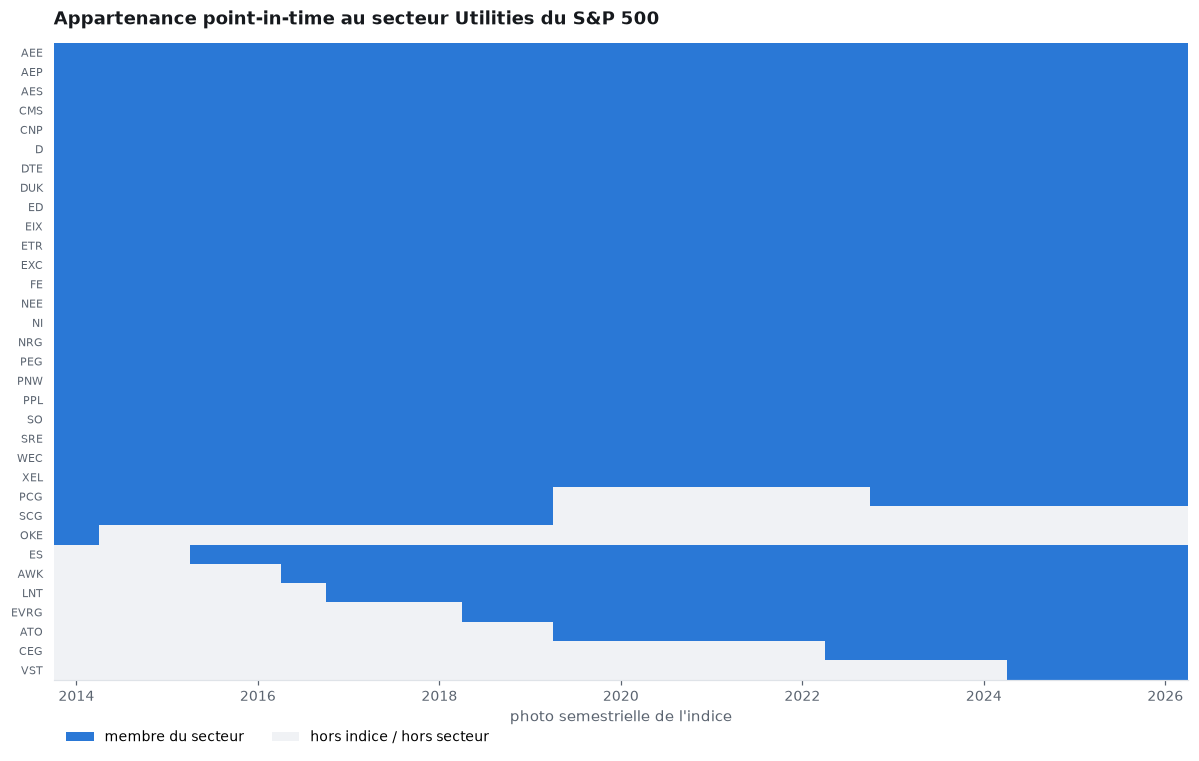

In [4]:
order = list(trad.columns[trad.any()])
order.sort(key=lambda t: (trad[t].values.argmax(), -trad[t].sum()))
mat = trad[order].T.astype(int).values

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(mat, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap(["#f0f2f5", BLUE]),
          interpolation="nearest", vmin=0, vmax=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7.5)
xt = range(0, len(trad.index), 4)
ax.set_xticks(list(xt)); ax.set_xticklabels([f"{trad.index[i]:%Y}" for i in xt])
ax.set_title("Appartenance point-in-time au secteur Utilities du S&P 500")
ax.grid(False); ax.set_xlabel("photo semestrielle de l'indice")
ax.legend(handles=[Patch(facecolor=BLUE, label="membre du secteur"),
                   Patch(facecolor="#f0f2f5", label="hors indice / hors secteur")],
          loc="upper left", bbox_to_anchor=(0, -.06), ncol=2)
plt.tight_layout(); plt.show()

La matrice n'est pas pleine. Les entrées se lisent en escalier à droite (ATO en 2019, CEG en 2022,
VST en 2024), et **une ligne présente un trou en plein milieu**. C'est celle qui nous intéresse.

---
## 3. PG&E : ce que le point-in-time capture sans qu'on lui demande rien

`PCG` (PG&E) est **hors de l'indice de juillet 2019 à juillet 2022** : dépôt de bilan en janvier
2019 après les incendies de Californie, retrait du S&P 500, puis réintégration après la sortie
de faillite.

PCG étant membre **aujourd'hui**, un univers bâti sur les constituants actuels l'inclurait sur
toute la période — et le traderait donc **pendant sa faillite**, en sachant implicitement qu'il
en est ressorti vivant.

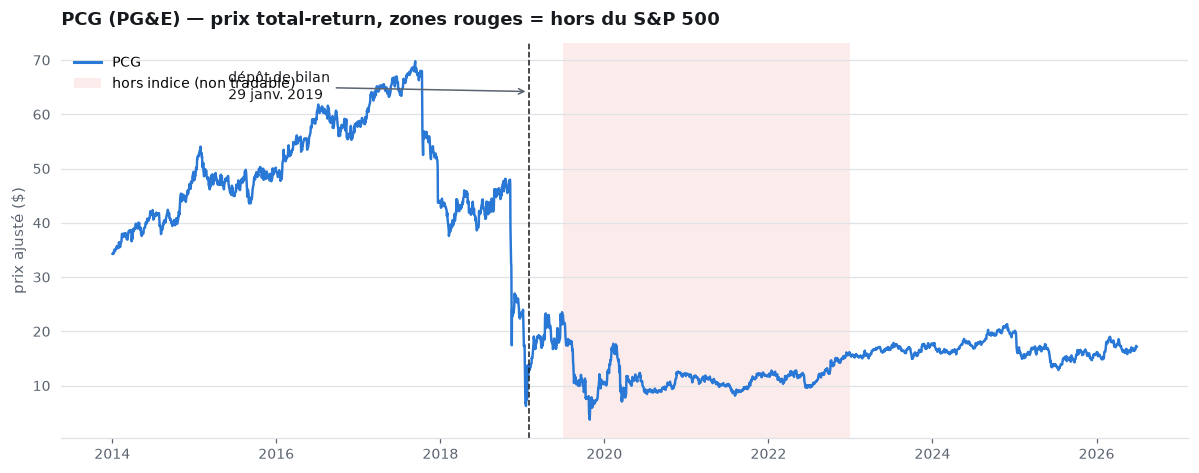

chute du 1er nov. 2017 au depot de bilan : -75.6 %
rebond de juil. 2020 a juil. 2022        : +13.4 %


In [5]:
pcg = close["PCG"].dropna()
inx = trad["PCG"]
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(pcg.index, pcg.values, color=BLUE, lw=1.6)

# zones hors indice, deduites des photos semestrielles
out = inx[~inx]
for d in out.index:
    ax.axvspan(d, d + pd.DateOffset(months=6), color="#e34948", alpha=.11, lw=0)
ax.axvline(pd.Timestamp("2019-01-29"), color=INK, lw=1, ls="--")
ax.annotate("dépôt de bilan\n29 janv. 2019", xy=(pd.Timestamp("2019-01-29"), pcg.max()*.92),
            xytext=(pd.Timestamp("2015-06-01"), pcg.max()*.90), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_title("PCG (PG&E) — prix total-return, zones rouges = hors du S&P 500")
ax.set_ylabel("prix ajusté ($)")
ax.legend(handles=[plt.Line2D([], [], color=BLUE, lw=2, label="PCG"),
                   Patch(facecolor="#e34948", alpha=.11, label="hors indice (non tradable)")],
          loc="upper left")
plt.tight_layout(); plt.show()

perte = pcg.loc["2017-11-01":"2019-01-29"]
print(f"chute du 1er nov. 2017 au depot de bilan : {100*(perte.iloc[-1]/perte.iloc[0]-1):.1f} %")
rebond = pcg.loc["2020-07-01":"2022-07-01"]
print(f"rebond de juil. 2020 a juil. 2022        : {100*(rebond.iloc[-1]/rebond.iloc[0]-1):+.1f} %")

Une stratégie naïve aurait traversé la chute **et** encaissé le rebond, sans jamais se demander
si le titre était empruntable pendant la procédure. La reconstruction point-in-time l'exclut
automatiquement — sans qu'aucune règle spécifique à PG&E n'ait été écrite. On a corrigé la cause,
pas le symptôme.

---
## 4. Le bug qui aurait tout invalidé : le recyclage de tickers

Une fois l'univers point-in-time construit, on télécharge les prix des 38 tickers. En regardant
les dates de début, on tombe sur ceci :

In [6]:
sus = val[val.status != "OK"].copy()
print(sus[["memb_first", "memb_last", "px_first", "px_last", "overlap_frac", "status"]]
      .to_string(formatters={
          "memb_first": lambda d: f"{d:%Y-%m}", "memb_last": lambda d: f"{d:%Y-%m}",
          "px_first": lambda d: f"{d:%Y-%m-%d}" if pd.notna(d) else "     -",
          "px_last":  lambda d: f"{d:%Y-%m-%d}" if pd.notna(d) else "     -"}))

       memb_first memb_last   px_first    px_last  overlap_frac    status
ticker                                                                   
GAS       2014-01   2016-07          -          -         0.000   NO_DATA
NU        2014-01   2015-01 2021-12-09 2026-06-29         0.000  RECYCLED
POM       2014-01   2016-01 2025-10-08 2026-06-29         0.000  RECYCLED
TE        2014-01   2016-07 2020-01-10 2026-06-29         0.000  RECYCLED
TEG       2014-01   2015-07 2015-12-22 2022-03-02         0.014  RECYCLED


`NU` a appartenu au secteur en **2014-2015**. Le fournisseur sert des prix à partir du
**9 décembre 2021**.

Ce n'est pas Northeast Utilities. C'est **Nu Holdings**, la néobanque brésilienne, qui a récupéré
le ticker après son IPO fin 2021. Idem pour `POM` (Pepco, racheté en 2016 — données depuis 2025),
`TE` (TECO, racheté en 2016 — données depuis 2020) et `TEG` (Integrys, racheté en 2015).

**Les tickers ne sont pas des identifiants pérennes.** Quand une société disparaît, son symbole
retourne au pot commun. Trois lettres n'identifient pas une entreprise : elles identifient un
emplacement sur un marché à un instant donné.

Le graphique ci-dessous rend le problème visible d'un coup d'œil.

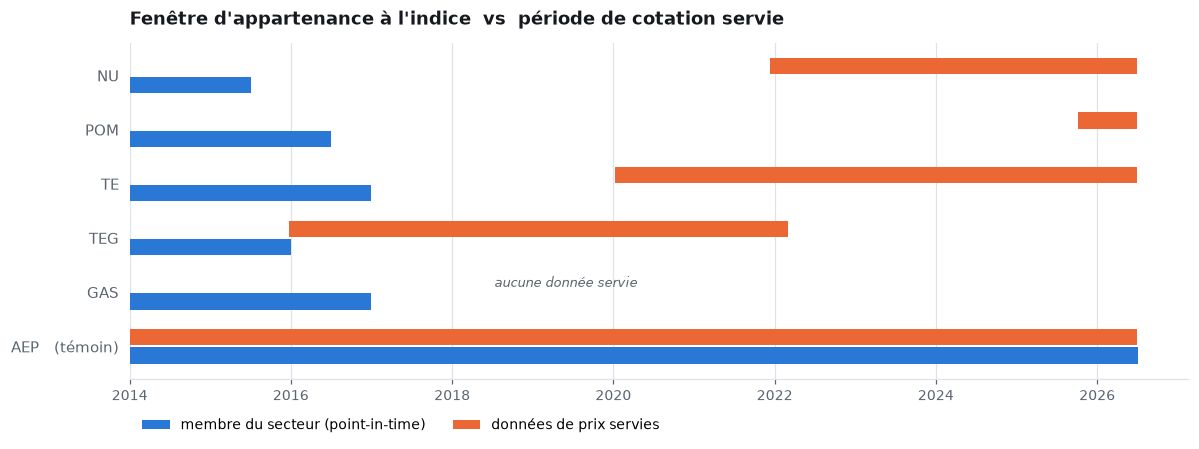

In [7]:
show = ["NU", "POM", "TE", "TEG", "GAS", "AEP"]     # AEP = temoin sain
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, t in enumerate(show):
    r = val.loc[t]
    ax.barh(i + .17, (r.memb_last - r.memb_first).days + 183, left=r.memb_first,
            height=.30, color=BLUE, zorder=3)
    if pd.notna(r.px_first):
        ax.barh(i - .17, (r.px_last - r.px_first).days, left=r.px_first,
                height=.30, color=ORANGE, zorder=3)
    else:
        ax.text(pd.Timestamp("2019-06-01"), i - .17, "aucune donnée servie",
                va="center", ha="center", fontsize=8.5, color=MUTED, style="italic")
ax.set_yticks(range(len(show)))
ax.set_yticklabels([f"{t}" + ("   (témoin)" if t == "AEP" else "") for t in show], fontsize=10)
ax.invert_yaxis(); ax.grid(False); ax.xaxis.grid(True)
ax.set_title("Fenêtre d'appartenance à l'indice  vs  période de cotation servie")
ax.legend(handles=[Patch(facecolor=BLUE, label="membre du secteur (point-in-time)"),
                   Patch(facecolor=ORANGE, label="données de prix servies")],
          loc="upper left", bbox_to_anchor=(0, -.08), ncol=2)
plt.tight_layout(); plt.show()

Pour `AEP`, les deux barres se superposent : le ticker désigne bien la même société.
Pour `NU`, `POM` et `TE`, **les deux barres ne se touchent même pas**.

### La règle de détection

On dispose de deux informations indépendantes : la fenêtre d'appartenance (reconstruction
point-in-time) et la période de cotation (fournisseur de prix). Si le ticker désigne la même
société dans les deux sources, **les deux intervalles doivent se recouvrir**.

$$\text{recouvrement} = \frac{\big|\,[\text{début cotation},\ \text{fin cotation}]\ \cap\ [\text{entrée indice},\ \text{sortie indice}]\,\big|}{\big|\,[\text{entrée indice},\ \text{sortie indice}]\,\big|}$$

Le contrôle est **bloquant**, pas indicatif : les tickers suspects sortent de l'univers.

### Ce qui se serait passé sans lui

Le backtest aurait testé la cointégration entre **Nu Holdings** et Duke Energy, l'aurait
peut-être trouvée significative, et aurait ouvert des positions. Aucune exception levée, aucun
test en échec, une courbe de P&L parfaitement lisse. **Les erreurs qui comptent ne provoquent
pas d'erreur.**

### Deux bugs dans le contrôle lui-même

Même un contrôle anti-erreur doit être vérifié. Les deux premières versions étaient fausses :

1. **Faux positif ONEOK.** `OKE` était classé recyclé à tort. Il n'apparaît que dans **un seul**
   snapshot (reclassé de *Utilities* vers *Energy* par GICS début 2014), donc sa fenêtre avait une
   durée nulle et le recouvrement divisait par zéro. Correction : être membre à la date $t$
   signifie l'être au moins jusqu'à la photo suivante — la fenêtre est élargie de 6 mois.
2. **Seuil à zéro exact.** La règle déclarait recyclé un recouvrement *exactement* nul. `TEG`
   a un recouvrement de **0,014** : Integrys a été racheté en juin 2015 et le ticker réattribué
   dès décembre, si bien que les intervalles se chevauchent de dix jours. Correction : seuil à 5 %.
   Un test binaire fondé sur une égalité exacte est fragile.

### L'angle mort qui subsiste

La règle compare deux intervalles ; elle détecterait mal un recyclage survenant **pendant** la
fenêtre d'appartenance. Le contrôle réellement robuste utiliserait un identifiant pérenne
(CUSIP, SEDOL, PERMNO) — c'est précisément ce que vendent les bases professionnelles.

---
## 5. Le forward-fill : une croyance testée, puis réfutée

Quand une série a un trou, le réflexe universel est le *forward-fill*. On ne le fait pas ici —
mais la raison n'est **pas** celle qu'on lit partout, et cette section raconte une erreur qu'on
a commise avant de la tester.

### L'argument habituel

« Reporter un prix crée un rendement nul suivi d'un rattrapage, donc la séquence *pas de mouvement
puis mouvement compensatoire* : c'est la signature du retour à la moyenne. Le forward-fill
fabriquerait donc le signal qu'on cherche. »

C'est ce qu'on avait écrit. **Testons-le** : on simule une marche aléatoire **pure**, donc sans
aucun retour à la moyenne. Si l'argument est correct, le forward-fill devrait faire rejeter le
test ADF plus souvent qu'il ne le devrait.

In [8]:
from statsmodels.tsa.stattools import adfuller
rng = np.random.default_rng(C.SEED)

def forward_fill(x, gaps):
    idx = np.arange(len(x))
    return x[np.maximum.accumulate(np.where(gaps, 0, idx))]

rej_t, rej_f, ac_t, ac_f = [], [], [], []
for _ in range(400):
    n = 750
    a, b = np.cumsum(rng.normal(0, .012, n)), np.cumsum(rng.normal(0, .012, n))
    s_true = a - b
    gaps = rng.random(n) < .05; gaps[0] = False
    s_ff = forward_fill(a, gaps) - b
    rej_t.append(adfuller(s_true, maxlag=1, regression="c")[1] < .05)
    rej_f.append(adfuller(s_ff,   maxlag=1, regression="c")[1] < .05)
    dt, df = np.diff(s_true), np.diff(s_ff)
    ac_t.append(np.corrcoef(dt[:-1], dt[1:])[0, 1])
    ac_f.append(np.corrcoef(df[:-1], df[1:])[0, 1])

print("Marche aleatoire PURE (aucun retour a la moyenne), 400 simulations, 5 % de trous\n")
print(f"  taux de rejet ADF a 5 %   sans ffill : {100*np.mean(rej_t):5.1f} %")
print(f"  taux de rejet ADF a 5 %   avec ffill : {100*np.mean(rej_f):5.1f} %")
print(f"  autocorr. lag-1 des diffs sans ffill : {np.mean(ac_t):+.4f}")
print(f"  autocorr. lag-1 des diffs avec ffill : {np.mean(ac_f):+.4f}")

Marche aleatoire PURE (aucun retour a la moyenne), 400 simulations, 5 % de trous

  taux de rejet ADF a 5 %   sans ffill :   6.8 %
  taux de rejet ADF a 5 %   avec ffill :   6.5 %
  autocorr. lag-1 des diffs sans ffill : -0.0016
  autocorr. lag-1 des diffs avec ffill : -0.0017


**Aucun effet.** L'argument est faux.

La raison, une fois qu'on la voit, est simple : le forward-fill **redistribue** les incréments
sans les modifier. Le jour manquant porte un rendement nul, le jour suivant porte la somme des
deux incréments. La somme totale est inchangée et, les incréments étant indépendants, la
covariance entre rendements consécutifs reste nulle. Il n'y a pas de « rattrapage
compensatoire » : il y a un **report**.

Vérifions maintenant sur un spread réellement mean-reverting (Ornstein-Uhlenbeck), et cherchons
ce que le forward-fill casse *vraiment*.

In [9]:
def ou_path(n, half_life=15, sigma=.01, rng=None):
    lam = np.log(2) / half_life
    s = np.zeros(n)
    for t in range(1, n):
        s[t] = s[t-1] * np.exp(-lam) + rng.normal(0, sigma)
    return s

def half_life_est(x):
    x = x[~np.isnan(x)]
    beta = np.polyfit(x[:-1], np.diff(x), 1)[0]
    return -np.log(2) / np.log(1 + beta) if -1 < beta < 0 else np.nan

def zscore(s, w=60):
    s = pd.Series(s)
    return ((s - s.rolling(w).mean()) / s.rolling(w).std()).values

rng = np.random.default_rng(C.SEED)
rows = []
for _ in range(300):
    n = 750
    s = ou_path(n, rng=rng)
    gaps = rng.random(n) < .05; gaps[0] = False
    s_ff = forward_fill(s, gaps)
    z_t, z_f = zscore(s), zscore(s_ff)
    ent_f = np.abs(z_f) > 2
    rows.append(dict(hl_true=half_life_est(s), hl_ff=half_life_est(s_ff),
                     n_t=int((np.abs(z_t) > 2).sum()), n_f=int(ent_f.sum()),
                     stale=int((ent_f & gaps).sum())))
r = pd.DataFrame(rows)
r["frac_stale"] = r.stale / r.n_f.clip(lower=1)

print("Spread OU (demi-vie vraie = 15 j), 5 % de trous, 300 simulations\n")
print(f"  demi-vie estimee   sans ffill : {r.hl_true.mean():6.2f} j")
print(f"  demi-vie estimee   avec ffill : {r.hl_ff.mean():6.2f} j   "
      f"(biais {100*(r.hl_ff.mean()/r.hl_true.mean()-1):+.1f} %)")
print(f"  signaux |z| > 2    sans ffill : {r.n_t.mean():6.1f}")
print(f"  signaux |z| > 2    avec ffill : {r.n_f.mean():6.1f}")
print(f"\n  >> signaux tombant un jour SANS COTATION : {r.stale.mean():.1f} par serie")
print(f"  >> soit {100*r.frac_stale.mean():.1f} % des signaux, a un prix qui n'a jamais existe")

Spread OU (demi-vie vraie = 15 j), 5 % de trous, 300 simulations

  demi-vie estimee   sans ffill :  13.95 j
  demi-vie estimee   avec ffill :  13.98 j   (biais +0.2 %)
  signaux |z| > 2    sans ffill :   67.8
  signaux |z| > 2    avec ffill :   67.6

  >> signaux tombant un jour SANS COTATION : 2.6 par serie
  >> soit 3.8 % des signaux, a un prix qui n'a jamais existe


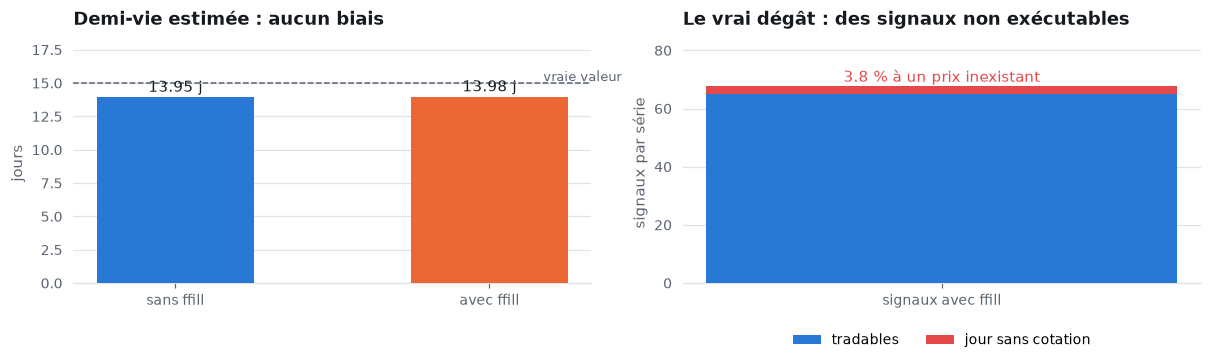

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
a = axes[0]
a.bar(["sans ffill", "avec ffill"], [r.hl_true.mean(), r.hl_ff.mean()],
      color=[BLUE, ORANGE], width=.5, zorder=3)
a.axhline(15, color=MUTED, ls="--", lw=1)
a.text(1.42, 15.15, "vraie valeur", fontsize=8.5, color=MUTED, ha="right")
a.set_title("Demi-vie estimée : aucun biais"); a.set_ylabel("jours"); a.set_ylim(0, 18)
for i, v in enumerate([r.hl_true.mean(), r.hl_ff.mean()]):
    a.text(i, v + .4, f"{v:.2f} j", ha="center", fontsize=9.5, color=INK)

a = axes[1]
tradables = r.n_f.mean() - r.stale.mean()
a.bar(["signaux avec ffill"], [tradables], color=BLUE, width=.4, zorder=3, label="tradables")
a.bar(["signaux avec ffill"], [r.stale.mean()], bottom=[tradables], color=RED, width=.4,
      zorder=3, label="jour sans cotation")
a.set_title("Le vrai dégât : des signaux non exécutables")
a.set_ylabel("signaux par série")
a.text(0, r.n_f.mean() + 1.6, f"{100*r.frac_stale.mean():.1f} % à un prix inexistant",
       ha="center", fontsize=9.5, color=RED)
a.set_ylim(0, r.n_f.mean() * 1.22); a.legend(loc="lower center", ncol=2, bbox_to_anchor=(.5, -.32))
plt.tight_layout(); plt.show()

### La conclusion, reformulée correctement

Le forward-fill ne corrompt **pas** la statistique du spread — il corrompt l'**exécution**.
Environ **4 % des signaux d'entrée tombent un jour où le titre ne cotait pas**. Le backtest ouvre
alors une position à un prix qui n'a jamais existé, puis enregistre un P&L sur une transaction
impossible. C'est une fuite d'exécution, de la même famille que trader au cours du jour où le
signal est calculé (le sujet de la Phase 6).

> **Ce qu'il faut retenir pour l'entretien.** Si tu avances l'argument du « retour à la moyenne
> fabriqué » face à quelqu'un qui a fait la simulation, tu perds toute crédibilité sur le reste.
> Pouvoir dire *« je l'ai cru, je l'ai testé, c'était faux, voici ce qui est vrai »* vaut plus que
> n'importe quelle justification apprise par cœur.

**Décision : aucun forward-fill.** Les NaN restent des NaN et sont traités explicitement, paire
par paire, au moment du test.

---
## 6. Pourquoi des prix total-return, et pas des prix bruts

Trois séries de prix existent pour une même action : le **prix brut** (affiché à l'écran), le
prix **ajusté des splits**, et le prix **total-return** (splits *et* dividendes réinvestis).
On a retenu le total-return, et le raisonnement est spécifique aux utilities.

Ces sociétés versent 3 à 4 % de dividende par an, et surtout ce rendement est **très dispersé**
d'un titre à l'autre. Le prix brut décroche du total-return d'un facteur qui croît avec le temps :

$$\log P^{\text{brut}}(t) \;\approx\; \log P^{\text{TR}}(t) \;-\; \delta\, t$$

Le spread calculé sur prix bruts contient donc un terme $-(\delta_A - \beta\,\delta_B)\,t$ :
**une dérive linéaire déterministe** qui n'a aucun contenu économique.

Commençons par mesurer la dispersion des rendements de dividende sur l'univers réel.

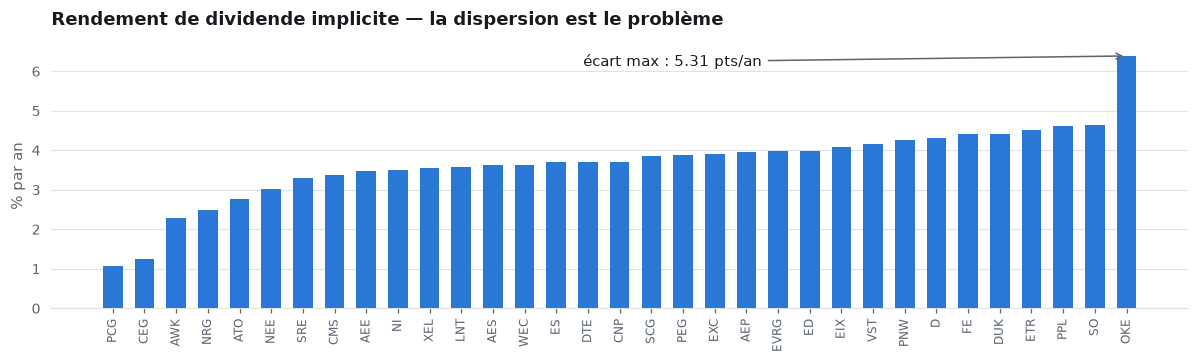

min 1.07 % (PCG)   max 6.39 % (OKE)


In [11]:
import yfinance as yf
raw_path = C.DATA_PROC / "prices_raw_all.parquet"
tk = sorted(trad.columns[trad.any()])
if raw_path.exists():
    raw = pd.read_parquet(raw_path)
else:
    raw = yf.download(tk, start=C.START, end=C.END, auto_adjust=False, progress=False)["Close"]
    raw.to_parquet(raw_path)

# rendement de dividende implicite = ecart annualise entre serie total-return et serie brute
yld = {}
for t in tk:
    a, b = close[t].dropna(), raw[t].dropna()
    i = a.index.intersection(b.index)
    if len(i) < 500:
        continue
    yrs = (i[-1] - i[0]).days / 365.25
    yld[t] = (a[i[-1]] / a[i[0]]) ** (1/yrs) - (b[i[-1]] / b[i[0]]) ** (1/yrs)
yld = pd.Series(yld).sort_values()

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(len(yld)), 100 * yld.values, color=BLUE, width=.62, zorder=3)
ax.set_xticks(range(len(yld))); ax.set_xticklabels(yld.index, rotation=90, fontsize=8)
ax.set_ylabel("% par an")
ax.set_title("Rendement de dividende implicite — la dispersion est le problème")
ax.annotate(f"écart max : {100*(yld.max()-yld.min()):.2f} pts/an",
            xy=(len(yld)-1, 100*yld.max()), xytext=(len(yld)*.45, 100*yld.max()*.96),
            fontsize=9.5, color=INK, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
plt.tight_layout(); plt.show()
print(f"min {100*yld.min():.2f} % ({yld.index[0]})   max {100*yld.max():.2f} % ({yld.index[-1]})")

L'écart va de **1,07 % (PCG) à 6,39 % (OKE)**, soit **5,3 points par an** entre deux titres du
*même secteur*. Deux détails valent d'être notés : PCG est en bas parce que PG&E a **suspendu son
dividende** pendant la faillite (2019-2022), et OKE est en haut parce que ONEOK est un
*midstream* à distribution élevée — ce qui explique aussi sa reclassification GICS de *Utilities*
vers *Energy* début 2014.

Sur une fenêtre de sélection de trois ans, un écart de 2 points par an injecte déjà ~6 % de dérive
dans le spread — du même ordre de grandeur que l'amplitude du spread lui-même.

### L'expérience : que change le choix de la série sur la sélection des paires ?

On teste les 465 paires sur une fenêtre in-sample type (2016-2018), une fois sur prix
total-return, une fois sur prix bruts, et on compare **les sélections obtenues**.

In [12]:
import itertools
from statsmodels.tsa.stattools import adfuller as adf

def spread_of(src, a, b, idx):
    la, lb = np.log(src[a].loc[idx]), np.log(src[b].loc[idx])
    beta, alpha = np.polyfit(lb, la, 1)
    return la - beta * lb - alpha

# Engle-Granger : OLS de log A sur log B, puis ADF sur le residu
def eg_pvalue(pa, pb, idx):
    la, lb = np.log(pa.loc[idx]), np.log(pb.loc[idx])
    beta, alpha = np.polyfit(lb, la, 1)
    return adf((la - beta * lb - alpha).values, maxlag=1)[1], beta, alpha

win = close.index[(close.index >= "2016-01-01") & (close.index <= "2018-12-31")]
rows = []
for a, b in itertools.combinations([t for t in tk if t in yld.index], 2):
    idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
    idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)
    if len(idx) < 600:
        continue
    d = spread_of(raw, a, b, idx) - spread_of(close, a, b, idx)   # terme de derive isole
    rows.append((a, b, eg_pvalue(close[a], close[b], idx)[0],
                       eg_pvalue(raw[a],   raw[b],   idx)[0],
                 abs(yld[a] - yld[b]), d.iloc[-1] - d.iloc[0]))
scan = pd.DataFrame(rows, columns=["A", "B", "p_TR", "p_raw", "gap_yield", "drift"])

sel_tr  = scan.p_TR  < .05
sel_raw = scan.p_raw < .05
perdues = scan[sel_tr & ~sel_raw]
creees  = scan[~sel_tr & sel_raw]

# Un desaccord peut n'etre qu'un alea de p-value au voisinage du seuil.
# On isole donc les basculements FRANCS : p passe de > 0.15 a < 0.05 (ou l'inverse).
franc_cree  = int(((scan.p_TR > .15) & (scan.p_raw < .05)).sum())
franc_perdu = int(((scan.p_raw > .15) & (scan.p_TR < .05)).sum())

print(f"paires testees sur 2016-2018 : {len(scan)}")
print(f"  significatives a 5 % sur TOTAL-RETURN : {sel_tr.sum()}")
print(f"  significatives a 5 % sur PRIX BRUTS   : {sel_raw.sum()}")
print(f"\n  desaccord entre les deux selections : {len(perdues)+len(creees)} paires "
      f"({100*(len(perdues)+len(creees))/len(scan):.1f} %)")
print(f"     dont vraies PERDUES : {len(perdues)}")
print(f"     dont fausses CREEES : {len(creees)}")
print(f"\n  MAIS une bonne part n'est qu'un alea de p-value pres du seuil :")
for nom, d in [("perdues", perdues), ("creees", creees)]:
    marg = int(((d.p_TR.between(.03, .08)) | (d.p_raw.between(.03, .08))).sum())
    print(f"     {nom:8s} : {marg}/{len(d)} marginales ({100*marg/len(d):.0f} %)")
print(f"\n  BASCULEMENTS FRANCS (p > 0.15 d'un cote, < 0.05 de l'autre) :")
print(f"     paires FABRIQUEES par les prix bruts : {franc_cree}")
print(f"     paires DETRUITES  par les prix bruts : {franc_perdu}")
print(f"\n  correlation |derive de dividende| vs |ecart de p-value| : "
      f"{scan.drift.abs().corr((scan.p_raw - scan.p_TR).abs()):.3f}")

paires testees sur 2016-2018 : 465
  significatives a 5 % sur TOTAL-RETURN : 112
  significatives a 5 % sur PRIX BRUTS   : 137

  desaccord entre les deux selections : 51 paires (11.0 %)
     dont vraies PERDUES : 13
     dont fausses CREEES : 38

  MAIS une bonne part n'est qu'un alea de p-value pres du seuil :
     perdues  : 11/13 marginales (85 %)
     creees   : 26/38 marginales (68 %)

  BASCULEMENTS FRANCS (p > 0.15 d'un cote, < 0.05 de l'autre) :
     paires FABRIQUEES par les prix bruts : 16
     paires DETRUITES  par les prix bruts : 1

  correlation |derive de dividende| vs |ecart de p-value| : 0.285


Il faut lire ce résultat avec précaution, et c'est le second endroit du notebook où l'intuition
de départ ne survit pas au test.

**Ce qu'on voulait conclure :** « les prix bruts fabriquent 38 fausses paires et en détruisent 13 ».
**Ce que les données autorisent réellement à dire** est plus nuancé : 85 % des paires perdues et
68 % des paires créées ont une p-value dans $[0{,}03\,;\,0{,}08]$. Ce sont des cas *marginaux* :
elles basculent parce qu'une p-value proche du seuil est bruitée, pas parce que la dérive de
dividende aurait changé quoi que ce soit de substantiel. Compter ces cas comme des « erreurs de
sélection » serait malhonnête.

**Ce qui résiste au test, en revanche, c'est l'asymétrie des basculements francs** — ceux où la
p-value passe de plus de 0,15 à moins de 0,05 :

| | Basculements francs |
|---|---|
| Paires **fabriquées** par les prix bruts | **16** |
| Paires **détruites** par les prix bruts | **1** |

Seize paires sans aucune relation d'équilibre sur les prix économiquement corrects deviennent
franchement « significatives » dès qu'on utilise les prix bruts. Une seule bascule dans l'autre
sens. La corrélation entre l'ampleur de la dérive de dividende et l'écart de p-value est de
**0,29** — positive, donc le mécanisme est bien là, mais partielle : la dérive explique une partie
du phénomène, pas tout.

**Le mécanisme, pour les cas francs.** Deux titres dont les prix total-return divergent
économiquement ne sont pas cointégrés. Si le titre qui monte le plus est aussi celui qui verse le
plus de dividende, alors sur prix bruts la dérive de dividende **annule** la divergence — et le
spread devient artificiellement plat, donc « stationnaire » au sens du test. On sélectionnerait une
paire sans relation d'équilibre, sur la base d'une compensation comptable fortuite.

Regardons un cas franc dans chaque sens, puis isolons le terme de dérive lui-même.

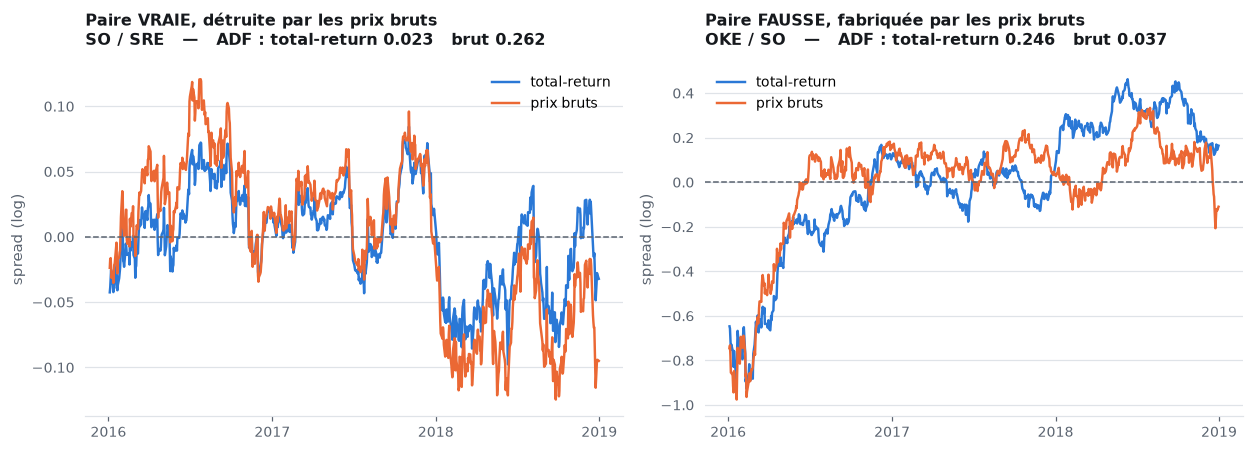

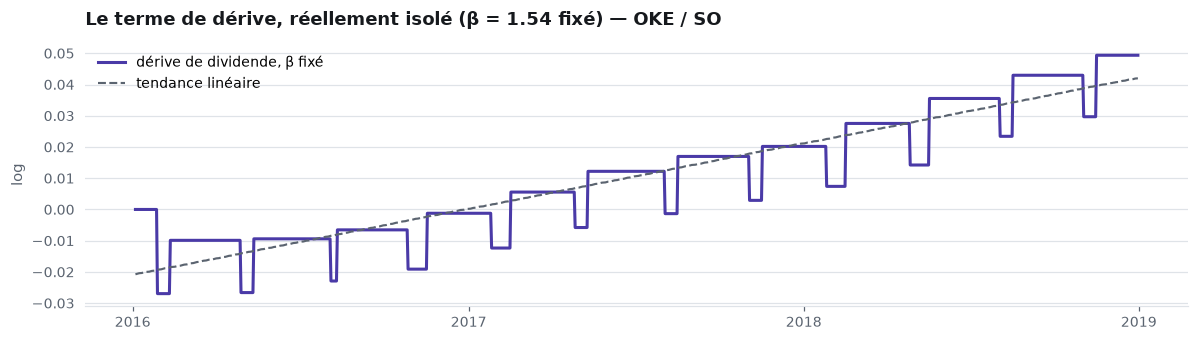

derive totale sur la fenetre : +0.0494 en log (+5.06 %)
R2 de l'ajustement lineaire  : 0.8571   -> la derive est bien deterministe et lineaire en t


In [13]:
# On illustre des basculements FRANCS, pas des cas marginaux.
franc_c = scan[(scan.p_TR > .15) & (scan.p_raw < .05)].assign(ad=lambda d: d.drift.abs())
best_fake = franc_c.sort_values("ad", ascending=False).iloc[0]
best_lost = scan[(scan.p_raw > .15) & (scan.p_TR < .05)].iloc[0]

import matplotlib.dates as mdates
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, row, titre in zip(axes, [best_lost, best_fake],
                          ["Paire VRAIE, détruite par les prix bruts",
                           "Paire FAUSSE, fabriquée par les prix bruts"]):
    a, b = row.A, row.B
    idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
    idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)
    for src, col, lab in [(close, BLUE, "total-return"), (raw, ORANGE, "prix bruts")]:
        ax.plot(idx, spread_of(src, a, b, idx).values, color=col, lw=1.6, label=lab)
    ax.axhline(0, color=MUTED, lw=1, ls="--")
    ax.set_title(f"{titre}\n{a} / {b}   —   ADF : total-return {row.p_TR:.3f}   "
                 f"brut {row.p_raw:.3f}", fontsize=10.5)
    ax.set_ylabel("spread (log)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(loc="best")
plt.tight_layout(); plt.show()

# ISOLER le terme de derive. Attention : faire simplement
#     spread(brut) - spread(total-return)
# ne l'isole PAS, car le beta est reestime separement sur chaque serie et la
# difference des deux betas introduit un terme stochastique qui domine.
# Il faut FIXER le beta (celui du total-return) et l'appliquer aux deux series.
a, b = best_fake.A, best_fake.B
idx = win.intersection(close[a].dropna().index).intersection(close[b].dropna().index)
idx = idx.intersection(raw[a].dropna().index).intersection(raw[b].dropna().index)

beta, _ = np.polyfit(np.log(close[b].loc[idx]), np.log(close[a].loc[idx]), 1)
drift = ((np.log(raw[a].loc[idx]) - np.log(close[a].loc[idx]))
         - beta * (np.log(raw[b].loc[idx]) - np.log(close[b].loc[idx])))
drift = drift - drift.iloc[0]

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(idx, drift.values, color=VIOLET, lw=2, label="dérive de dividende, β fixé")
t = np.arange(len(idx))
fit = np.polyfit(t, drift.values, 1)
ax.plot(idx, np.polyval(fit, t), color=MUTED, lw=1.4, ls="--", label="tendance linéaire")
ax.set_title(f"Le terme de dérive, réellement isolé (β = {beta:.2f} fixé) — {a} / {b}")
ax.set_ylabel("log"); ax.legend(loc="best")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

r2 = np.corrcoef(np.polyval(fit, t), drift.values)[0, 1] ** 2
print(f"derive totale sur la fenetre : {drift.iloc[-1]:+.4f} en log "
      f"({100*(np.exp(drift.iloc[-1])-1):+.2f} %)")
print(f"R2 de l'ajustement lineaire  : {r2:.4f}   "
      f"-> la derive est bien deterministe et lineaire en t")

À gauche, le spread total-return oscille autour de zéro — c'est une relation d'équilibre. Le
spread sur prix bruts décroche à partir de 2018 : la dérive a détruit la stationnarité, et le test
rejette une paire authentiquement cointégrée.

À droite, l'inverse, et c'est le cas le plus instructif. Le spread total-return (bleu) monte
franchement en 2018, jusqu'à +0,4 : les deux titres divergent, il n'y a aucune relation
d'équilibre. Le spread sur prix bruts (orange), lui, reste bien plus plat — la dérive de dividende
**compense** la divergence économique. Le test conclut à tort à la cointégration.

Le troisième graphique isole le terme de dérive. Un piège s'y cache, et il valait la peine d'être
corrigé : calculer simplement `spread(brut) − spread(total-return)` **n'isole rien**, parce que le
β est réestimé séparément sur chaque série et que l'écart entre les deux β introduit un terme
stochastique qui domine tout. En **fixant** le β, on obtient ce que la théorie prédit : une tendance linéaire, avec un $R^2$ de
**0,86**.

Et la forme en **escalier** est la confirmation du mécanisme. Un dividende n'est pas versé en
continu : il est détaché quatre fois par an, à date fixe. Chaque marche est un détachement sur
l'une des deux jambes. La dérive n'est donc pas une abstraction de modèle — on voit littéralement
chaque versement s'accumuler dans le spread.

> **La conclusion à formuler en entretien.** Les deux séries de prix produisent des sélections
> qui diffèrent sur 11 % des paires. L'essentiel de ce désaccord est du bruit de p-value au
> voisinage du seuil — le dire est plus honnête que d'annoncer « 38 fausses paires ». Mais
> l'asymétrie des basculements francs, **16 contre 1**, est robuste : les prix bruts fabriquent de
> la cointégration apparente bien plus souvent qu'ils n'en détruisent. Le choix de la série de
> prix n'est pas un détail de préparation des données — **c'est une décision qui change la
> sélection elle-même.**

Le total-return est par ailleurs le bon objet **économique** — une position long/short encaisse
réellement le dividende de la jambe longue et le paie sur la jambe courte.

> **La fuite résiduelle qu'il faut savoir nommer.** Les prix ajustés sont *rétro*-ajustés : chaque
> nouveau dividende modifie rétroactivement toute la série historique. La série de 2018 telle que
> je la télécharge en 2026 n'est pas celle qu'un trader observait en 2018. L'effet est de second
> ordre ici (les deux jambes sont ajustées dans le même sens, la position est long/short) mais il
> existe — et le nommer spontanément distingue quelqu'un qui a réfléchi de quelqu'un qui a suivi
> un tutoriel.

---
## 7. Le survivorship résiduel : quantifié, et surtout **orienté**

Le point-in-time corrige la composition. Il ne corrige pas l'indisponibilité des prix des
sociétés disparues. Voyons ce qui reste.

tickers exclus (5) : ['GAS', 'NU', 'POM', 'TE', 'TEG']
slots d'appartenance : 732 bruts -> 708 conserves (3.3 % perdus)
dernier snapshot avec des pertes : 2016-07


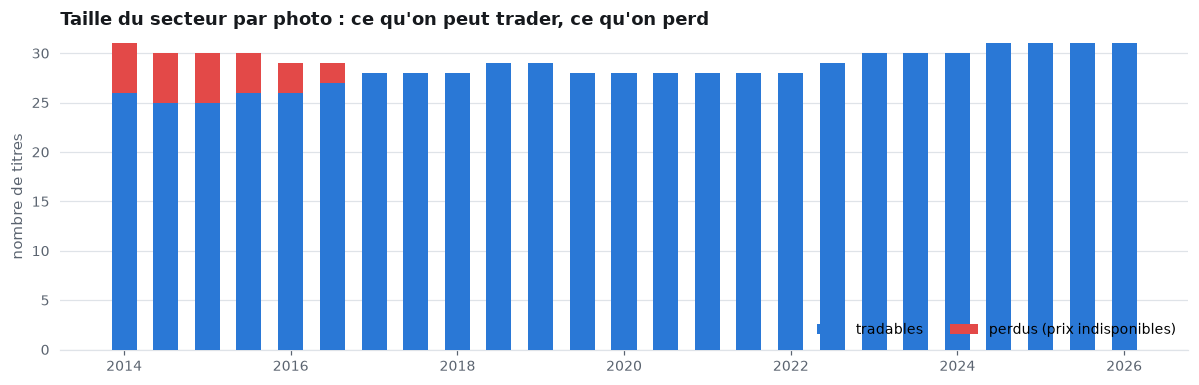

In [14]:
lost = sorted(set(memb.columns[memb.any()]) - set(trad.columns[trad.any()]))
per = pd.DataFrame({"brut": memb.sum(axis=1), "tradable": trad.sum(axis=1)})
per["perdus"] = per.brut - per.tradable
slots_all, slots_kept = int(memb.values.sum()), int(trad.values.sum())

print(f"tickers exclus ({len(lost)}) : {lost}")
print(f"slots d'appartenance : {slots_all} bruts -> {slots_kept} conserves "
      f"({100*(slots_all-slots_kept)/slots_all:.1f} % perdus)")
print(f"dernier snapshot avec des pertes : {per[per.perdus>0].index[-1]:%Y-%m}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(per.index, per.tradable, width=110, color=BLUE, zorder=3, label="tradables")
ax.bar(per.index, per.perdus, bottom=per.tradable, width=110, color=RED, zorder=3,
       label="perdus (prix indisponibles)")
ax.set_title("Taille du secteur par photo : ce qu'on peut trader, ce qu'on perd")
ax.set_ylabel("nombre de titres")
ax.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

Les pertes sont **entièrement concentrées sur 2014-2016** et **nulles à partir de janvier 2017**.

### La direction du biais — le point le plus important

Les cinq noms perdus sont tous sortis de l'indice **par acquisition**, aucun par faillite :

| Ticker | Ce qui s'est passé |
|---|---|
| `GAS` | AGL Resources, racheté par Southern Company (2016). Aucune donnée : perte sèche. |
| `NU`  | Northeast Utilities, **renommé Eversource (ES)** en 2015. Perte apparente seulement : la série `ES` remonte à 2014 et porte l'historique. |
| `POM` | Pepco Holdings, racheté par Exelon (2016). |
| `TE`  | TECO Energy, racheté par Emera (2016). |
| `TEG` | Integrys Energy, racheté par WEC (2015). |

Or une OPA est précisément l'événement qui brise une cointégration de la façon la plus brutale :
le cours de la cible saute au prix d'offre puis se **fige**, définitivement décorrélé de son
secteur. Une position vendeuse sur la cible au moment de l'annonce subit une perte instantanée
qui ne se résorbe **jamais** — le retour à la moyenne n'a pas lieu.

> **Conclusion à formuler telle quelle :** exclure ces noms retire de l'échantillon des scénarios
> de perte extrême et irréversible. **Le biais résiduel surestime donc la performance.** C'est le
> cas le plus dangereux, parce qu'un biais favorable ne se signale jamais de lui-même : on n'a
> aucune raison de le chercher, puisque les résultats sont bons.
>
> Conséquence pratique : le premier fold (sélection 2014-2016) est le plus exposé. L'honnêteté
> consiste à reporter son résultat **séparément** plutôt que de l'agréger aux autres.

### Deux zones grises assumées

- **EVRG** — Evergy est né en 2018 de la fusion Westar / Great Plains. L'historique servi remonte
  à 2014 : ce sont les prix de Westar, le prédécesseur. Défendable, mais à savoir.
- **SCG** — SCANA affiche un recouvrement de 0,69 : l'historique servi commence en juillet 2015
  alors que la société était membre depuis 2014. Historique tronqué, identité cohérente. Conservé.

---
## 8. Où on en est, et le chiffre qui ouvre la Phase 3

In [15]:
n_max = int(trad.sum(axis=1).max()); n_min = int(trad.sum(axis=1).min())
pairs = n_max * (n_max - 1) // 2
print(f"univers tradable            : {int(trad.any().sum())} tickers")
print(f"taille du secteur par date  : {n_min} a {n_max} titres")
print(f"paires testables au maximum : {pairs}")
print(f"\nsous H0 -- aucune paire n'est reellement cointegree -- un test a 5 %")
print(f"en declarerait tout de meme ~{0.05*pairs:.0f} SIGNIFICATIVES, par pur hasard.")

univers tradable            : 33 tickers
taille du secteur par date  : 25 a 31 titres
paires testables au maximum : 465

sous H0 -- aucune paire n'est reellement cointegree -- un test a 5 %
en declarerait tout de meme ~23 SIGNIFICATIVES, par pur hasard.


**C'est le chiffre qui ouvre la Phase 3.** Si le screener trouve 30 paires « significatives »
alors qu'on en attend ~23 par pur hasard, on n'a presque rien trouvé. Tout l'enjeu de la
sélection honnête est là : comparer ce qu'on trouve à ce que le hasard produirait, puis corriger
(Bonferroni, Benjamini-Hochberg) et **figer la sélection avant la période de trading**.

### Le filtre de liquidité : pourquoi il n'est pas dans ce notebook

Le plan prévoit un univers d'actions **liquides**. Aucun filtre n'a été appliqué — délibérément.
Filtrer maintenant reviendrait à calculer le volume médian sur **toute** la période 2014-2026,
puis à ne garder que les titres au-dessus d'un seuil. On utiliserait donc, pour décider quoi
trader en 2015, l'information « ce titre sera encore liquide en 2025 » — information corrélée à
la survie et au succès de l'entreprise. **C'est un survivorship bias déguisé en critère technique.**

Le filtre sera recalculé **à chaque fold, sur la fenêtre in-sample uniquement**, exactement comme
la sélection des paires. Il arrive donc en Phase 3.

### Récapitulatif des garde-fous

| Garde-fou | Contre quoi | Où |
|---|---|---|
| Appartenance point-in-time | Survivorship sur la composition | `src/universe.py` |
| Contrôle d'identité bloquant | Recyclage de tickers | `validate_identity` |
| Prix total-return | Dérive de dividende dans le spread | `src/data.py` |
| Aucun forward-fill | Signaux les jours sans cotation | `src/data.py` |
| Dénominateur « titres en vie » | Suppression de séances valides | `_clean` |
| Cache disque des révisions | Non-reproductibilité de l'univers | `data/raw/wiki/` |
| Échec bruyant sur requête ratée | Univers silencieusement tronqué | `_get` |
| Décision d'univers datée | Data snooping au niveau du secteur | `docs/01_universe_decision.md` |
| Filtre de liquidité reporté | Survivorship déguisé en critère technique | Phase 3 |

---

**Phase suivante — Phase 2 :** les briques statistiques. Engle-Granger, ADF, demi-vie par
ajustement d'un Ornstein-Uhlenbeck, et le z-score en **fenêtre glissante causale** (le z-score
calculé sur la moyenne de toute la période est la fuite la plus fréquente du pairs trading).